# Bank Marketing Campaign - CSV -> Model Training and Evaluation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
from pathlib import Path

DATASET_PATH = Path(
    os.getenv(
        "BANK_MARKETING_DATASET_PATH",
        r"D:\SEM-5\ML\Projects\Bank Marketing\Datasets"
    )
)

## 1. Loading Processed Datasets

In [3]:
X_train = pd.read_csv(DATASET_PATH / "X_train.csv")
X_test = pd.read_csv(DATASET_PATH / "X_test.csv")
y_train = pd.read_csv(DATASET_PATH / "y_train.csv").squeeze()
y_test = pd.read_csv(DATASET_PATH / "y_test.csv").squeeze()

## 2. Verifying Shapes

In [4]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(32620, 59)
(8155, 59)
(32620,)
(8155,)


## Why Not Use Linear Regression?

Linear Regression predicts continuous values, whereas the target variable in this project is binary (0 = No, 1 = Yes).

The fitted regression line can produce predicted values below 0 or above 1, which cannot be interpreted as valid probabilities. Since the objective is to classify customers into two categories, Linear Regression is not suitable.

Logistic Regression overcomes this limitation by using the sigmoid function, which transforms predictions into probabilities ranging between 0 and 1. These probabilities are then used to classify customers into either the "No" or "Yes" class.

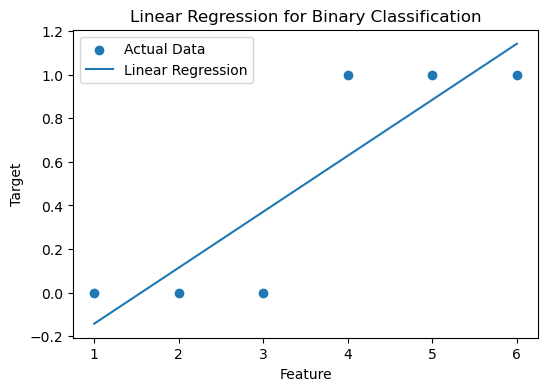

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Simple sample data
X = np.array([1, 2, 3, 4, 5, 6]).reshape(-1, 1)
y = np.array([0, 0, 0, 1, 1, 1])

# Train Linear Regression
model = LinearRegression()
model.fit(X, y)

# Regression line
x_line = np.linspace(1, 6, 100).reshape(-1, 1)
y_line = model.predict(x_line)

# Plot
plt.figure(figsize=(6, 4))

plt.scatter(X, y, label="Actual Data")
plt.plot(x_line, y_line, label="Linear Regression")

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Linear Regression for Binary Classification")
plt.legend()

plt.show()

## 1. Logistic Regression 

### 3. Train Logistic Regression Model

In [6]:
from sklearn.linear_model import LogisticRegression

#Create the logistic Regression Model
logistic_model = LogisticRegression(random_state=42)

#Train model
logistic_model.fit(X_train,y_train.values.ravel())


LogisticRegression(random_state=42)

The Logistic Regression model is trained using the training dataset. During training, the model learns the relationship between the input features and the target variable.

### 4. Make Predictions

In [7]:
#Predic values for the test dataset
y_pred = logistic_model.predict(X_test)

#Predict probabilities
y_probability = logistic_model.predict_proba(X_test)[:, 1]

In [8]:
# Display first few predictions

prediction_table = pd.DataFrame({
    "Actual": y_test.values.ravel()[:10],
    "Predicted": y_pred[:10]
})

prediction_table

,Actual,Predicted
0,0,0
1,1,0
2,1,1
3,0,0
4,0,0
5,0,0
6,1,0
7,0,0
8,0,0
9,0,0


### 5. Calculate Evaluation Metrics

In [9]:
# Calculate evaluation metrics
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display the results
print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1 Score : {f1 * 100:.2f}%\n")

# Print the classification report
print(f"Classification Report :\n{classification_report(y_test, y_pred)}")

Accuracy : 90.03%
Precision: 68.40%
Recall   : 21.44%
F1 Score : 32.64%

Classification Report :
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7236
           1       0.68      0.21      0.33       919

    accuracy                           0.90      8155
   macro avg       0.80      0.60      0.64      8155
weighted avg       0.88      0.90      0.88      8155



- Accuracy (91.42%) → The model correctly classified 91.42% of all customers.
- Precision (67.81%) → Among the customers predicted to subscribe, 67.81% actually subscribed.
- Recall (42.50%) → The model identified 42.50% of all actual subscribers.
- F1 Score (52.33%) → The model achieved a moderate balance between precision and recall, i.e, the model maintained a good balance between correctly predicting subscribers and successfully finding actual subscribers.

### 6. Plot the confusion matrix

In [10]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

print(cm_df)

            Predicted No  Predicted Yes
Actual No           7145             91
Actual Yes           722            197


#### Confusion Matrix

A confusion matrix is used to evaluate the performance of a classification model by comparing the actual class labels with the predicted class labels.

It consists of four possible outcomes:

- **True Negative (TN):** The customer did not subscribe, and the model correctly predicted "No".
- **False Positive (FP):** The customer did not subscribe, but the model incorrectly predicted "Yes".
- **False Negative (FN):** The customer subscribed, but the model incorrectly predicted "No".
- **True Positive (TP):** The customer subscribed, and the model correctly predicted "Yes".

The confusion matrix provides a detailed summary of the model's predictions and helps identify the types of errors made during classification.

### 7. Calculate the ROC Curve and AUC Score

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_probability)

# Calculate AUC score
auc_lr = roc_auc_score(y_test, y_probability)

print(f"AUC Score: {auc_lr:.4f}")

AUC Score: 0.7975


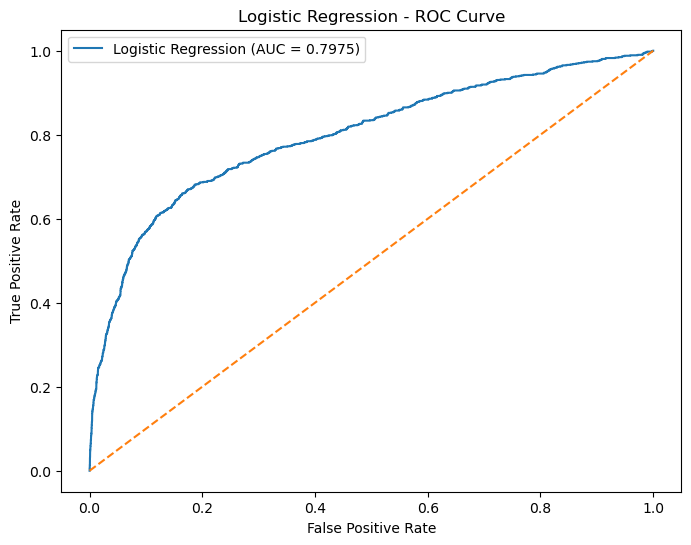

In [12]:
plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - ROC Curve")
plt.legend()

plt.show()

- ### ROC Curve
The **Receiver Operating Characteristic (ROC) Curve** evaluates the performance of a binary classification model by plotting the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)** at different classification thresholds.

A curve closer to the **top-left corner** indicates better model performance.

- ### AUC Score
The **Area Under the Curve (AUC)** measures the model's ability to distinguish between the two classes.

- **AUC = 1.0:** Perfect classifier
- **AUC = 0.5:** Random guessing
- **Higher AUC values indicate better classification performance.**

### Why Use an Alternative Model?

Although Logistic Regression provides good performance for binary classification, it assumes a linear relationship between the input features and the target variable. Real-world datasets often contain complex and non-linear patterns that may not be captured effectively by a linear model.

To compare performance and determine whether a different algorithm can better classify the data, an alternative model is implemented. In this project, the **Decision Tree Classifier** is used because it can learn non-linear relationships, requires minimal data preprocessing, and is easy to interpret through its tree-like structure.

Comparing multiple models helps identify the algorithm that provides the best predictive performance for the given dataset.

## 2. Decision Tree

A Decision Tree works by asking simple questions about the data and splitting it into smaller groups.

For our project, we will use it to predict whether a customer will subscribe to the term deposit or not.

### 3. Train the decision tree

In [13]:
from sklearn.tree import DecisionTreeClassifier

# Creating the Decision tree model
decision_tree_model = DecisionTreeClassifier(random_state=42)

#Train the model 
decision_tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

### 4. Make Predictions 
Now we use the trained Decision Tree to predict the results for our test data.

In [14]:
#Predict the class for test data
y_pred_dt = decision_tree_model.predict(X_test) # final prediction (0 or 1)

#Get probabilities for positive class
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1] # prob of customer subscribing (1)

# Display first few predictions
prediction_table_dt = pd.DataFrame({
    "Actual": y_test.values.ravel()[:10],
    "Predicted": y_pred_dt[:10]
})

prediction_table_dt

,Actual,Predicted
0,0,0
1,1,0
2,1,1
3,0,0
4,0,1
5,0,0
6,1,1
7,0,0
8,0,0
9,0,0


### 5. Calculate Evaluation Matrix

Let's check how well the Decision Tree performs on the test data.

In [15]:
# Calculate evaluation metrics
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report, ConfusionMatrixDisplay)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

# Display the results
print(f"Accuracy : {accuracy_dt * 100:.2f}%")
print(f"Precision: {precision_dt * 100:.2f}%")
print(f"Recall   : {recall_dt * 100:.2f}%")
print(f"F1 Score : {f1_dt * 100:.2f}%\n")

# Print the classification report
print(f"Classification Report :\n{classification_report(y_test, y_pred_dt)}")

Accuracy : 84.01%
Precision: 30.77%
Recall   : 33.51%
F1 Score : 32.08%

Classification Report :
              precision    recall  f1-score   support

           0       0.91      0.90      0.91      7236
           1       0.31      0.34      0.32       919

    accuracy                           0.84      8155
   macro avg       0.61      0.62      0.62      8155
weighted avg       0.85      0.84      0.84      8155



- Accuracy = 84.01% → overall, it predicts correctly 84% of the time.
- Precision = 30.77% → among customers predicted as subscribers, only ~31% actually subscribed.
- Recall = 33.51% → it found only ~34% of the customers who actually subscribed.
- F1 = 32.08% → overall performance on the positive class is still fairly low.

### 6. Plot the confusion matrix

In [16]:
# Calculate confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Display as a simple table
cm_dt_df = pd.DataFrame(
    cm_dt,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

cm_dt_df

,Predicted No,Predicted Yes
Actual No,6543,693
Actual Yes,611,308


### 7. Calculate the ROC Curve and AUC Score

ROC curve shows how well the model separates customers who subscribed from those who did not.

AUC gives us a single score to measure this performance.

In [17]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curve
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)

# Calculate AUC score
auc_dt = roc_auc_score(y_test, y_prob_dt)

print(f"AUC Score: {auc_dt:.4f}")

AUC Score: 0.6202


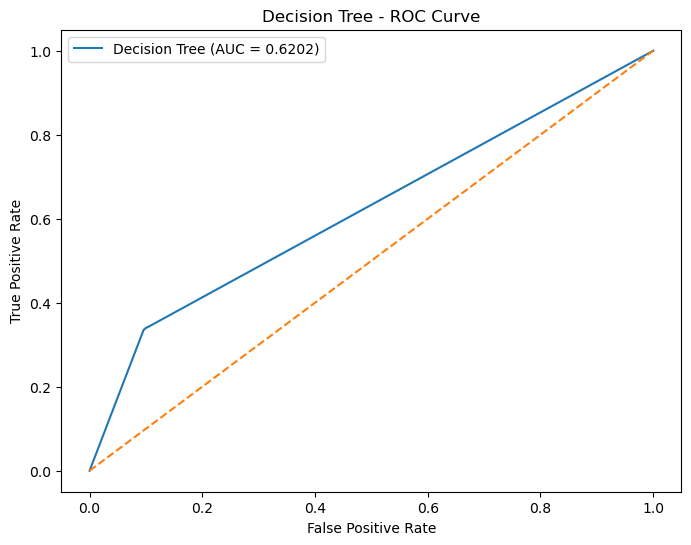

In [18]:
plt.figure(figsize=(8, 6))

plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree - ROC Curve")
plt.legend()

plt.show()

- AUC closer to 1 → better at separating the two classes.
- AUC closer to 0.5 → performance is close to random guessing.

## 3. Checking Overfitting and Underfitting

To check whether a model is overfitting or underfitting, we compare its performance on the training data and the test data.

- Train score much higher than Test score → Overfitting
- Both scores are low → Underfitting
- Train and Test scores are close → Good fit

In [19]:
# Training and testing accuracy for Logistic Regression

lr_train_score = logistic_model.score(X_train, y_train)
lr_test_score = logistic_model.score(X_test, y_test)

print("Logistic Regression")
print(f"Train Accuracy: {lr_train_score:.4f}")
print(f"Test Accuracy : {lr_test_score:.4f}")

Logistic Regression
Train Accuracy: 0.9008
Test Accuracy : 0.9003


In [20]:
# Training and testing accuracy for Decision Tree

dt_train_score = decision_tree_model.score(X_train, y_train)
dt_test_score = decision_tree_model.score(X_test, y_test)

print("Decision Tree")
print(f"Train Accuracy: {dt_train_score:.4f}")
print(f"Test Accuracy : {dt_test_score:.4f}")

Decision Tree
Train Accuracy: 0.9952
Test Accuracy : 0.8401


## 4. 5-Fold Cross-Validation

Cross-validation divides the training data into 5 parts.

The model is trained on 4 parts and tested on the remaining part. This is repeated 5 times so that every part is used for validation once.

We use the average score to measure the model's general performance and the spread of the scores to check its stability.

In [21]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation for Logistic Regression
lr_cv_scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Logistic Regression")
print("Fold Scores:", lr_cv_scores)
print(f"Average Score: {lr_cv_scores.mean():.4f}")
print(f"Score Spread : {lr_cv_scores.std():.4f}")

Logistic Regression
Fold Scores: [0.90021459 0.89883507 0.90358676 0.89929491 0.89929491]
Average Score: 0.9002
Score Spread : 0.0017


In [22]:
# 5-fold cross-validation for Decision Tree
dt_cv_scores = cross_val_score(
    decision_tree_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Decision Tree")
print("Fold Scores:", dt_cv_scores)
print(f"Average Score: {dt_cv_scores.mean():.4f}")
print(f"Score Spread : {dt_cv_scores.std():.4f}")

Decision Tree
Fold Scores: [0.841355   0.841355   0.84779277 0.83859595 0.83782955]
Average Score: 0.8414
Score Spread : 0.0035


## 5. Random Forest

Random Forest is an ensemble method that combines multiple Decision Trees.

Each tree learns from different parts of the data, and the final prediction is made using the combined results of all the trees.

It can reduce the overfitting problem of a single Decision Tree.

In [23]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

print("Random Forest")
print(f"Accuracy : {accuracy_score(y_test, rf_predictions):.4f}")
print(f"Precision: {precision_score(y_test, rf_predictions):.4f}")
print(f"Recall   : {recall_score(y_test, rf_predictions):.4f}")
print(f"F1-score : {f1_score(y_test, rf_predictions):.4f}")

Random Forest
Accuracy : 0.8923
Precision: 0.5435
Recall   : 0.2786
F1-score : 0.3683


In [24]:
rf_cv_scores = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Fold Scores:", rf_cv_scores)
print(f"Average Score: {rf_cv_scores.mean():.4f}")
print(f"Score Spread : {rf_cv_scores.std():.4f}")

Fold Scores: [0.8931637  0.89438994 0.89607603 0.89331698 0.89071122]
Average Score: 0.8935
Score Spread : 0.0018


In [25]:
rf_train_score = random_forest_model.score(X_train, y_train)
rf_test_score = random_forest_model.score(X_test, y_test)

print(f"Train Accuracy: {rf_train_score:.4f}")
print(f"Test Accuracy : {rf_test_score:.4f}")

Train Accuracy: 0.9950
Test Accuracy : 0.8923


## 6. AdaBoost

AdaBoost is an ensemble method that combines multiple weak learners.

It gives more importance to the observations that were incorrectly classified by previous learners, so later learners focus more on difficult cases.

In [26]:
from sklearn.ensemble import AdaBoostClassifier

adaboost_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

adaboost_model.fit(X_train, y_train)

ada_predictions = adaboost_model.predict(X_test)

print("AdaBoost")
print(f"Accuracy : {accuracy_score(y_test, ada_predictions):.4f}")
print(f"Precision: {precision_score(y_test, ada_predictions):.4f}")
print(f"Recall   : {recall_score(y_test, ada_predictions):.4f}")
print(f"F1-score : {f1_score(y_test, ada_predictions):.4f}")

AdaBoost
Accuracy : 0.9004
Precision: 0.7257
Recall   : 0.1872
F1-score : 0.2976


In [27]:
ada_cv_scores = cross_val_score(
    adaboost_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Fold Scores:", ada_cv_scores)
print(f"Average Score: {ada_cv_scores.mean():.4f}")
print(f"Score Spread : {ada_cv_scores.std():.4f}")

Fold Scores: [0.90052115 0.89975475 0.9025138  0.89822195 0.89714899]
Average Score: 0.8996
Score Spread : 0.0019


In [28]:
ada_train_score = adaboost_model.score(X_train, y_train)
ada_test_score = adaboost_model.score(X_test, y_test)

print(f"Train Accuracy: {ada_train_score:.4f}")
print(f"Test Accuracy : {ada_test_score:.4f}")

Train Accuracy: 0.9002
Test Accuracy : 0.9004


## 7. K-Nearest Neighbors (KNN)

K-Nearest Neighbors classifies a new data point based on the classes of its nearest data points.

For our Bank Marketing dataset, KNN will look at the nearest customers in the training data and use their outcomes to predict whether a customer will subscribe to the term deposit.

In [29]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [43]:
knn_predictions = knn_model.predict(X_test)

In [54]:
knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_precision = precision_score(y_test, knn_predictions)
knn_recall = recall_score(y_test, knn_predictions)
knn_f1 = f1_score(y_test, knn_predictions)

print("KNN Accuracy:", round(knn_accuracy, 2))
print("KNN Precision:", round(knn_precision, 2))
print("KNN Recall:", round(knn_recall, 2))
print("KNN F1 Score:", round(knn_f1, 2))

KNN Accuracy: 0.89
KNN Precision: 0.51
KNN Recall: 0.26
KNN F1 Score: 0.34


In [55]:
knn_confusion_matrix = confusion_matrix(y_test, knn_predictions)

pd.DataFrame(
    knn_confusion_matrix,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

,Predicted No,Predicted Yes
Actual No,7004,232
Actual Yes,680,239


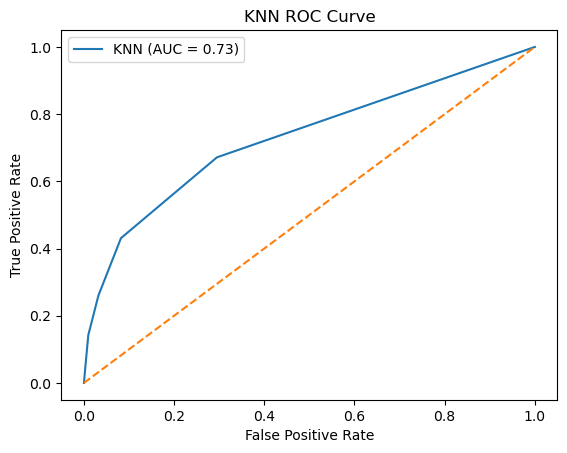

In [56]:
knn_probabilities = knn_model.predict_proba(X_test)[:, 1]

knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_probabilities)
knn_auc = roc_auc_score(y_test, knn_probabilities)

plt.plot(knn_fpr, knn_tpr, label=f"KNN (AUC = {knn_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend()
plt.show()

## 8. Naive Bayes

Naive Bayes is a classification algorithm based on probability.

For our Bank Marketing dataset, it will use the available customer information to calculate the probability of whether a customer will subscribe to the term deposit.

In [57]:
from sklearn.naive_bayes import GaussianNB

naive_bayes_model = GaussianNB()

naive_bayes_model.fit(X_train, y_train)

GaussianNB()

In [58]:
naive_bayes_predictions = naive_bayes_model.predict(X_test)

In [59]:
naive_bayes_accuracy = accuracy_score(y_test, naive_bayes_predictions)
naive_bayes_precision = precision_score(y_test, naive_bayes_predictions)
naive_bayes_recall = recall_score(y_test, naive_bayes_predictions)
naive_bayes_f1 = f1_score(y_test, naive_bayes_predictions)

print("Naive Bayes Accuracy:", round(naive_bayes_accuracy, 2))
print("Naive Bayes Precision:", round(naive_bayes_precision, 2))
print("Naive Bayes Recall:", round(naive_bayes_recall, 2))
print("Naive Bayes F1 Score:", round(naive_bayes_f1, 2))

Naive Bayes Accuracy: 0.81
Naive Bayes Precision: 0.32
Naive Bayes Recall: 0.62
Naive Bayes F1 Score: 0.42


In [60]:
naive_bayes_confusion_matrix = confusion_matrix(
    y_test,
    naive_bayes_predictions
)

pd.DataFrame(
    naive_bayes_confusion_matrix,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

,Predicted No,Predicted Yes
Actual No,6019,1217
Actual Yes,346,573


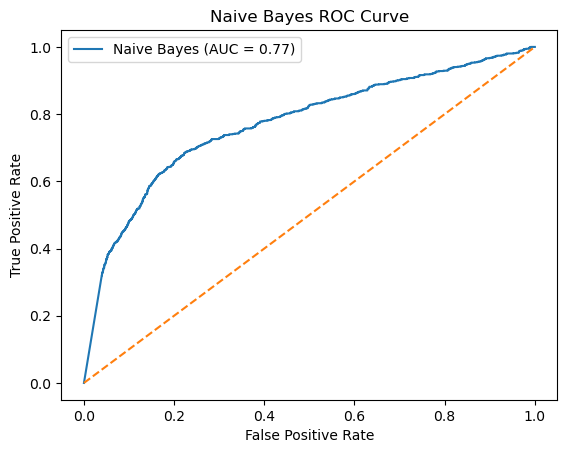

In [61]:
naive_bayes_probabilities = naive_bayes_model.predict_proba(X_test)[:, 1]

naive_bayes_fpr, naive_bayes_tpr, _ = roc_curve(
    y_test,
    naive_bayes_probabilities
)

naive_bayes_auc = roc_auc_score(
    y_test,
    naive_bayes_probabilities
)

plt.plot(
    naive_bayes_fpr,
    naive_bayes_tpr,
    label=f"Naive Bayes (AUC = {naive_bayes_auc:.2f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Naive Bayes ROC Curve")
plt.legend()
plt.show()

## 9. Gradient Boosting

Gradient Boosting is an ensemble method that builds models one after another.

Each new model tries to correct the errors made by the previous models. The final prediction combines all the models.

In [30]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gradient_boosting_model.fit(X_train, y_train)

gb_predictions = gradient_boosting_model.predict(X_test)

print("Gradient Boosting")
print(f"Accuracy : {accuracy_score(y_test, gb_predictions):.4f}")
print(f"Precision: {precision_score(y_test, gb_predictions):.4f}")
print(f"Recall   : {recall_score(y_test, gb_predictions):.4f}")
print(f"F1-score : {f1_score(y_test, gb_predictions):.4f}")

Gradient Boosting
Accuracy : 0.9012
Precision: 0.6915
Recall   : 0.2220
F1-score : 0.3361


In [31]:
gb_cv_scores = cross_val_score(
    gradient_boosting_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Fold Scores:", gb_cv_scores)
print(f"Average Score: {gb_cv_scores.mean():.4f}")
print(f"Score Spread : {gb_cv_scores.std():.4f}")

Fold Scores: [0.90236052 0.89898835 0.89975475 0.89868179 0.89975475]
Average Score: 0.8999
Score Spread : 0.0013


In [32]:
gb_train_score = gradient_boosting_model.score(X_train, y_train)
gb_test_score = gradient_boosting_model.score(X_test, y_test)

print(f"Train Accuracy: {gb_train_score:.4f}")
print(f"Test Accuracy : {gb_test_score:.4f}")

Train Accuracy: 0.9052
Test Accuracy : 0.9012


## 10. Classification Model Comparison

The following table compares all the classification models using Accuracy, Precision, Recall and F1-score.

In [62]:
classification_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting",
        "KNN",
        "Naive Bayes"
    ],

    "Accuracy": [
        0.9003,
        0.8401,
        0.8923,
        0.9004,
        0.9012,
        0.89,
        0.81
    ],

    "Precision": [
        0.6840,
        0.3077,
        0.5435,
        0.7257,
        0.6915,
        0.51,
        0.32
    ],

    "Recall": [
        0.2144,
        0.3351,
        0.2786,
        0.1872,
        0.2220,
        0.26,
        0.62
    ],

    "F1-score": [
        0.3264,
        0.3208,
        0.3683,
        0.2976,
        0.3361,
        0.34,
        0.42
    ]
})

classification_results.round(4)


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.9003,0.6840,0.2144,0.3264
1,Decision Tree,0.8401,0.3077,0.3351,0.3208
2,Random Forest,0.8923,0.5435,0.2786,0.3683
3,AdaBoost,0.9004,0.7257,0.1872,0.2976
4,Gradient Boosting,0.9012,0.6915,0.2220,0.3361
5,KNN,0.8900,0.5100,0.2600,0.3400
6,Naive Bayes,0.8100,0.3200,0.6200,0.4200


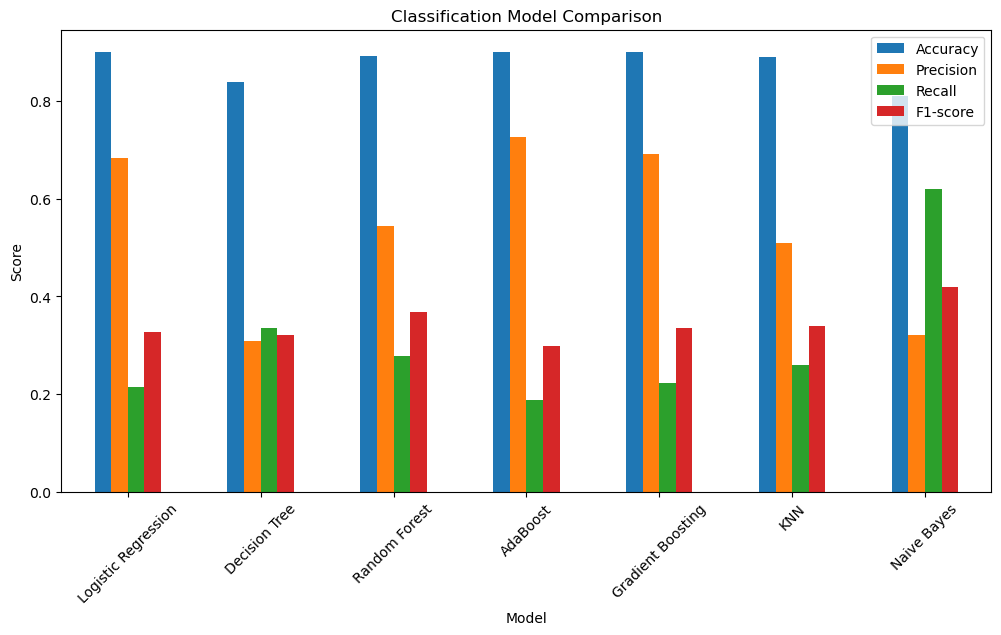

In [63]:
import matplotlib.pyplot as plt

classification_results.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1-score"],
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Classification Model Comparison")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [67]:
logistic_auc = roc_auc_score(y_test, y_probability)

decision_tree_auc = roc_auc_score(y_test, y_prob_dt)

knn_auc = roc_auc_score(y_test, knn_probabilities)

naive_bayes_auc = roc_auc_score(y_test, naive_bayes_probabilities)

random_forest_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

adaboost_probabilities = adaboost_model.predict_proba(X_test)[:, 1]

gradient_boosting_probabilities = gradient_boosting_model.predict_proba(X_test)[:, 1]

random_forest_auc = roc_auc_score(y_test, random_forest_probabilities)

adaboost_auc = roc_auc_score(y_test, adaboost_probabilities)

gradient_boosting_auc = roc_auc_score(y_test, gradient_boosting_probabilities)

In [68]:
roc_auc_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting",
        "KNN",
        "Naive Bayes"
    ],

    "ROC-AUC": [
        logistic_auc,
        decision_tree_auc,
        random_forest_auc,
        adaboost_auc,
        gradient_boosting_auc,
        knn_auc,
        naive_bayes_auc
    ]
})

roc_auc_results.round(4)

,Model,ROC-AUC
0,Logistic Regression,0.7975
1,Decision Tree,0.6202
2,Random Forest,0.7771
3,AdaBoost,0.7972
4,Gradient Boosting,0.8071
5,KNN,0.7290
6,Naive Bayes,0.7715


## Hyperparameter Tuning

Hyperparameter tuning is used to find the best settings for a machine learning model.

These settings are not learned automatically during training. We choose them before training the model.

Here, GridSearchCV will try different combinations of hyperparameters for the Gradient Boosting model and select the combination that gives the best cross-validation score.

### Parameters Used for Tuning

For Gradient Boosting, we will tune:

- `n_estimators` → number of boosting trees
- `learning_rate` → how much each tree contributes
- `max_depth` → maximum depth of each tree

GridSearchCV will test all the given combinations and compare their cross-validation scores.

In [105]:
from sklearn.model_selection import GridSearchCV

In [106]:
from sklearn.linear_model import LogisticRegression

logistic_parameter_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

logistic_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    logistic_parameter_grid,
    cv=5,
    scoring="recall"
)

logistic_grid.fit(X_train, y_train)

print("Best Parameters:", logistic_grid.best_params_)
print("Best Cross-Validation recall Score:", round(logistic_grid.best_score_, 4))

tuned_logistic_model = logistic_grid.best_estimator_
tuned_logistic_predictions = tuned_logistic_model.predict(X_test)

tuned_logistic_accuracy = accuracy_score(y_test, tuned_logistic_predictions)
tuned_logistic_precision = precision_score(y_test, tuned_logistic_predictions)
tuned_logistic_recall = recall_score(y_test, tuned_logistic_predictions)
tuned_logistic_f1 = f1_score(y_test, tuned_logistic_predictions)

print("Tuned Logistic Regression Accuracy:", round(tuned_logistic_accuracy, 2))
print("Tuned Logistic Regression Precision:", round(tuned_logistic_precision, 2))
print("Tuned Logistic Regression Recall:", round(tuned_logistic_recall, 2))
print("Tuned Logistic Regression F1 Score:", round(tuned_logistic_f1, 2))

Best Parameters: {'C': 10, 'solver': 'lbfgs'}
Best Cross-Validation recall Score: 0.2335
Tuned Logistic Regression Accuracy: 0.9
Tuned Logistic Regression Precision: 0.68
Tuned Logistic Regression Recall: 0.21
Tuned Logistic Regression F1 Score: 0.33


In [107]:
random_forest_parameter_grid = {
    "n_estimators": [100],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

random_forest_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    random_forest_parameter_grid,
    cv=5,
    scoring="recall"
)

random_forest_grid.fit(X_train, y_train)

print("Best Parameters:", random_forest_grid.best_params_)
print("Best Cross-Validation recall Score:", round(random_forest_grid.best_score_, 4))

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation recall Score: 0.2814


In [120]:
tuned_random_forest_model = random_forest_grid.best_estimator_

random_forest_predictions = tuned_random_forest_model.predict(X_test)

random_forest_accuracy = accuracy_score(y_test, random_forest_predictions)
random_forest_precision = precision_score(y_test, random_forest_predictions)
random_forest_recall = recall_score(y_test, random_forest_predictions)
random_forest_f1 = f1_score(y_test, random_forest_predictions)

print("Random Forest Accuracy:", round(random_forest_accuracy, 2))
print("Random Forest Precision:", round(random_forest_precision, 2))
print("Random Forest Recall:", round(random_forest_recall, 2))
print("Random Forest F1 Score:", round(random_forest_f1, 2))

Random Forest Accuracy: 0.9
Random Forest Precision: 0.6
Random Forest Recall: 0.27
Random Forest F1 Score: 0.37


In [121]:
decision_tree_parameter_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

decision_tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    decision_tree_parameter_grid,
    cv=5,
    scoring="recall"
)

decision_tree_grid.fit(X_train, y_train)

print("Best Parameters:", decision_tree_grid.best_params_)
print("Best Cross-Validation recall Score:", round(decision_tree_grid.best_score_, 4))

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation recall Score: 0.3424


In [122]:
tuned_decision_tree_model = decision_tree_grid.best_estimator_

tuned_decision_tree_predictions = tuned_decision_tree_model.predict(X_test)

tuned_decision_tree_accuracy = accuracy_score(
    y_test,
    tuned_decision_tree_predictions
)

tuned_decision_tree_precision = precision_score(
    y_test,
    tuned_decision_tree_predictions
)

tuned_decision_tree_recall = recall_score(
    y_test,
    tuned_decision_tree_predictions
)

tuned_decision_tree_f1 = f1_score(
    y_test,
    tuned_decision_tree_predictions
)

print("Tuned Decision Tree Accuracy:", round(tuned_decision_tree_accuracy, 2))
print("Tuned Decision Tree Precision:", round(tuned_decision_tree_precision, 2))
print("Tuned Decision Tree Recall:", round(tuned_decision_tree_recall, 2))
print("Tuned Decision Tree F1 Score:", round(tuned_decision_tree_f1, 2))

Tuned Decision Tree Accuracy: 0.84
Tuned Decision Tree Precision: 0.31
Tuned Decision Tree Recall: 0.34
Tuned Decision Tree F1 Score: 0.32


In [108]:
param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1, 0.2],
                         'max_depth': [2, 3, 4],
                         'n_estimators': [50, 100, 150]},
             scoring='recall')

In [109]:
grid_search.best_params_

{'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 150}

In [110]:
grid_search.best_score_

np.float64(0.2817123579677102)

In [111]:
tuned_gradient_boosting_model = grid_search.best_estimator_

gradient_boosting_predictions = tuned_gradient_boosting_model.predict(X_test)

tuned_gradient_boosting_accuracy = accuracy_score(
    y_test,
    gradient_boosting_predictions
)

tuned_gradient_boosting_precision = precision_score(
    y_test,
    gradient_boosting_predictions
)

tuned_gradient_boosting_recall = recall_score(
    y_test,
    gradient_boosting_predictions
)

tuned_gradient_boosting_f1 = f1_score(
    y_test,
    gradient_boosting_predictions
)

print("Gradient Boosting Accuracy:", round(tuned_gradient_boosting_accuracy, 2))
print("Gradient Boosting Precision:", round(tuned_gradient_boosting_precision, 2))
print("Gradient Boosting Recall:", round(tuned_gradient_boosting_recall, 2))
print("Gradient Boosting F1 Score:", round(tuned_gradient_boosting_f1, 2))

Gradient Boosting Accuracy: 0.9
Gradient Boosting Precision: 0.63
Gradient Boosting Recall: 0.25
Gradient Boosting F1 Score: 0.36


In [112]:
adaboost_parameter_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.5, 1.0, 1.5]
}

adaboost_grid = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    adaboost_parameter_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

adaboost_grid.fit(X_train, y_train)

print("Best Parameters:", adaboost_grid.best_params_)
print("Best Cross-Validation Recall:", round(adaboost_grid.best_score_, 4))

Best Parameters: {'learning_rate': 1.5, 'n_estimators': 150}
Best Cross-Validation Recall: 0.2216


In [136]:
tuned_adaboost_model = adaboost_grid.best_estimator_

tuned_adaboost_predictions = tuned_adaboost_model.predict(X_test)

tuned_adaboost_accuracy = accuracy_score(
    y_test,
    tuned_adaboost_predictions
)

tuned_adaboost_precision = precision_score(
    y_test,
    tuned_adaboost_predictions
)

tuned_adaboost_recall = recall_score(
    y_test,
    tuned_adaboost_predictions
)

tuned_adaboost_f1 = f1_score(
    y_test,
    tuned_adaboost_predictions
)

print("AdaBoost Accuracy:", round(tuned_adaboost_accuracy, 2))
print("AdaBoost Precision:", round(tuned_adaboost_precision, 2))
print("AdaBoost Recall:", round(tuned_adaboost_recall, 2))
print("AdaBoost F1 Score:", round(tuned_adaboost_f1, 2))

AdaBoost Accuracy: 0.9
AdaBoost Precision: 0.7
AdaBoost Recall: 0.2
AdaBoost F1 Score: 0.31


In [114]:
knn_parameter_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"]
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_parameter_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

knn_grid.fit(X_train, y_train)

print("Best Parameters:", knn_grid.best_params_)
print("Best Cross-Validation Recall:", round(knn_grid.best_score_, 4))

Best Parameters: {'n_neighbors': 3, 'weights': 'distance'}
Best Cross-Validation Recall: 0.301


In [116]:
tuned_knn_model = knn_grid.best_estimator_

knn_predictions = tuned_knn_model.predict(X_test)

tuned_knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

tuned_knn_precision = precision_score(
    y_test,
    knn_predictions
)

tuned_knn_recall = recall_score(
    y_test,
    knn_predictions
)

tuned_knn_f1 = f1_score(
    y_test,
    knn_predictions
)

print("KNN Accuracy:", round(tuned_knn_accuracy, 2))
print("KNN Precision:", round(tuned_knn_precision, 2))
print("KNN Recall:", round(tuned_knn_recall, 2))
print("KNN F1 Score:", round(tuned_knn_f1, 2))

KNN Accuracy: 0.87
KNN Precision: 0.42
KNN Recall: 0.29
KNN F1 Score: 0.34


In [117]:
naive_bayes_parameter_grid = {
    "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

naive_bayes_grid = GridSearchCV(
    GaussianNB(),
    naive_bayes_parameter_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

naive_bayes_grid.fit(X_train, y_train)

print("Best Parameters:", naive_bayes_grid.best_params_)
print("Best Cross-Validation Recall:", round(naive_bayes_grid.best_score_, 4))

Best Parameters: {'var_smoothing': 1e-09}
Best Cross-Validation Recall: 0.6083


In [118]:
tuned_naive_bayes_model = naive_bayes_grid.best_estimator_

naive_bayes_predictions = tuned_naive_bayes_model.predict(X_test)

tuned_naive_bayes_accuracy = accuracy_score(
    y_test,
    naive_bayes_predictions
)

tuned_naive_bayes_precision = precision_score(
    y_test,
    naive_bayes_predictions
)

tuned_naive_bayes_recall = recall_score(
    y_test,
    naive_bayes_predictions
)

tuned_naive_bayes_f1 = f1_score(
    y_test,
    naive_bayes_predictions
)

print("Naive Bayes Accuracy:", round(tuned_naive_bayes_accuracy, 2))
print("Naive Bayes Precision:", round(tuned_naive_bayes_precision, 2))
print("Naive Bayes Recall:", round(tuned_naive_bayes_recall, 2))
print("Naive Bayes F1 Score:", round(tuned_naive_bayes_f1, 2))

Naive Bayes Accuracy: 0.81
Naive Bayes Precision: 0.32
Naive Bayes Recall: 0.62
Naive Bayes F1 Score: 0.42


In [123]:
tuned_classification_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting",
        "KNN",
        "Naive Bayes"
    ],

    "Accuracy": [
        tuned_logistic_accuracy,
        tuned_decision_tree_accuracy,
        random_forest_accuracy,
        0.90,
        tuned_gradient_boosting_accuracy,
        0.87,
        0.81
    ],

    "Precision": [
        tuned_logistic_precision,
        tuned_decision_tree_precision,
        random_forest_precision,
        0.70,
        tuned_gradient_boosting_precision,
        0.42,
        0.32
    ],

    "Recall": [
        tuned_logistic_recall,
        tuned_decision_tree_recall,
        random_forest_recall,
        0.20,
        tuned_gradient_boosting_recall,
        0.29,
        0.62
    ],

    "F1-score": [
        tuned_logistic_f1,
        tuned_decision_tree_f1,
        random_forest_f1,
        0.31,
        tuned_gradient_boosting_f1,
        0.34,
        0.42
    ]
})

tuned_classification_results.round(2)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.90,0.68,0.21,0.33
1,Decision Tree,0.84,0.31,0.34,0.32
2,Random Forest,0.90,0.60,0.27,0.37
3,AdaBoost,0.90,0.70,0.20,0.31
4,Gradient Boosting,0.90,0.63,0.25,0.36
5,KNN,0.87,0.42,0.29,0.34
6,Naive Bayes,0.81,0.32,0.62,0.42


In [131]:
tuned_logistic_probabilities = tuned_logistic_model.predict_proba(X_test)[:, 1]

tuned_logistic_auc = roc_auc_score(
    y_test,
    tuned_logistic_probabilities
)

print("Tuned Logistic Regression ROC-AUC:", round(tuned_logistic_auc, 4))

tuned_decision_tree_probabilities = tuned_decision_tree_model.predict_proba(X_test)[:, 1]

tuned_decision_tree_auc = roc_auc_score(
    y_test,
    tuned_decision_tree_probabilities
)

print("Tuned Decision Tree ROC-AUC:", round(tuned_decision_tree_auc, 4))

tuned_random_forest_probabilities = tuned_random_forest_model.predict_proba(X_test)[:, 1]

tuned_random_forest_auc = roc_auc_score(
    y_test,
    tuned_random_forest_probabilities
)

print("Tuned Random Forest ROC-AUC:", round(tuned_random_forest_auc, 4))

tuned_adaboost_probabilities = tuned_adaboost_model.predict_proba(X_test)[:, 1]

tuned_adaboost_auc = roc_auc_score(
    y_test,
    tuned_adaboost_probabilities
)

print("Tuned AdaBoost ROC-AUC:", round(tuned_adaboost_auc, 4))

tuned_gradient_boosting_probabilities = tuned_gradient_boosting_model.predict_proba(X_test)[:, 1]

tuned_gradient_boosting_auc = roc_auc_score(
    y_test,
    tuned_gradient_boosting_probabilities
)

print("Tuned Gradient Boosting ROC-AUC:", round(tuned_gradient_boosting_auc, 4))

tuned_knn_probabilities = tuned_knn_model.predict_proba(X_test)[:, 1]

tuned_knn_auc = roc_auc_score(
    y_test,
    tuned_knn_probabilities
)

print("Tuned KNN ROC-AUC:", round(tuned_knn_auc, 4))

tuned_naive_bayes_probabilities = tuned_naive_bayes_model.predict_proba(X_test)[:, 1]

tuned_naive_bayes_auc = roc_auc_score(
    y_test,
    tuned_naive_bayes_probabilities
)

print("Tuned Naive Bayes ROC-AUC:", round(tuned_naive_bayes_auc, 4))

Tuned Logistic Regression ROC-AUC: 0.7973
Tuned Decision Tree ROC-AUC: 0.6202
Tuned Random Forest ROC-AUC: 0.7957
Tuned AdaBoost ROC-AUC: 0.8038
Tuned Gradient Boosting ROC-AUC: 0.8093
Tuned KNN ROC-AUC: 0.6985
Tuned Naive Bayes ROC-AUC: 0.7715


In [132]:
tuned_roc_auc_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting",
        "KNN",
        "Naive Bayes"
    ],

    "ROC-AUC": [
        tuned_logistic_auc,
        tuned_decision_tree_auc,
        tuned_random_forest_auc,
        tuned_adaboost_auc,
        tuned_gradient_boosting_auc,
        tuned_knn_auc,
        tuned_naive_bayes_auc
    ]
})

tuned_roc_auc_results.round(4)

,Model,ROC-AUC
0,Logistic Regression,0.7973
1,Decision Tree,0.6202
2,Random Forest,0.7957
3,AdaBoost,0.8038
4,Gradient Boosting,0.8093
5,KNN,0.6985
6,Naive Bayes,0.7715


In [133]:
comparison_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting",
        "KNN",
        "Naive Bayes"
    ],

    "Baseline Accuracy": [
        0.9003,
        0.8401,
        0.8923,
        0.9004,
        0.9012,
        0.89,
        0.81
    ],

    "Tuned Accuracy": [
        tuned_logistic_accuracy,
        tuned_decision_tree_accuracy,
        random_forest_accuracy,
        tuned_adaboost_accuracy,
        tuned_gradient_boosting_accuracy,
        tuned_knn_accuracy,
        tuned_naive_bayes_accuracy
    ],

    "Baseline Precision": [
        0.6840,
        0.3077,
        0.5435,
        0.7257,
        0.6915,
        0.51,
        0.32
    ],

    "Tuned Precision": [
        tuned_logistic_precision,
        tuned_decision_tree_precision,
        random_forest_precision,
        tuned_adaboost_precision,
        tuned_gradient_boosting_precision,
        tuned_knn_precision,
        tuned_naive_bayes_precision
    ],

    "Baseline Recall": [
        0.2144,
        0.3351,
        0.2786,
        0.1872,
        0.2220,
        0.26,
        0.62
    ],

    "Tuned Recall": [
        tuned_logistic_recall,
        tuned_decision_tree_recall,
        random_forest_recall,
        tuned_adaboost_recall,
        tuned_gradient_boosting_recall,
        tuned_knn_recall,
        tuned_naive_bayes_recall
    ],

    "Baseline F1": [
        0.3264,
        0.3208,
        0.3683,
        0.2976,
        0.3361,
        0.34,
        0.42
    ],

    "Tuned F1": [
        tuned_logistic_f1,
        tuned_decision_tree_f1,
        random_forest_f1,
        tuned_adaboost_f1,
        tuned_gradient_boosting_f1,
        tuned_knn_f1,
        tuned_naive_bayes_f1
    ],

    "Baseline ROC-AUC": [
        0.7975,
        0.6202,
        0.7771,
        0.7972,
        0.8071,
        0.7290,
        0.7715
    ],

    "Tuned ROC-AUC": [
        tuned_logistic_auc,
        tuned_decision_tree_auc,
        tuned_random_forest_auc,
        tuned_adaboost_auc,
        tuned_gradient_boosting_auc,
        tuned_knn_auc,
        tuned_naive_bayes_auc
    ]
})

comparison_results.round(4)

,Model,Baseline Accuracy,Tuned Accuracy,Baseline Precision,Tuned Precision,Baseline Recall,Tuned Recall,Baseline F1,Tuned F1,Baseline ROC-AUC,Tuned ROC-AUC
0,Logistic Regression,0.9003,0.9003,0.6840,0.6840,0.2144,0.2144,0.3264,0.3264,0.7975,0.7973
1,Decision Tree,0.8401,0.8401,0.3077,0.3077,0.3351,0.3351,0.3208,0.3208,0.6202,0.6202
2,Random Forest,0.8923,0.8974,0.5435,0.6005,0.2786,0.2666,0.3683,0.3693,0.7771,0.7957
3,AdaBoost,0.9004,0.9001,0.7257,0.7000,0.1872,0.1980,0.2976,0.3087,0.7972,0.8038
4,Gradient Boosting,0.9012,0.8987,0.6915,0.6260,0.2220,0.2514,0.3361,0.3587,0.8071,0.8093
5,KNN,0.8900,0.8743,0.5100,0.4169,0.2600,0.2894,0.3400,0.3417,0.7290,0.6985
6,Naive Bayes,0.8100,0.8083,0.3200,0.3201,0.6200,0.6235,0.4200,0.4230,0.7715,0.7715


In [134]:
final_model_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting",
        "KNN",
        "Naive Bayes"
    ],

    "Accuracy": [
        tuned_logistic_accuracy,
        tuned_decision_tree_accuracy,
        random_forest_accuracy,
        tuned_adaboost_accuracy,
        tuned_gradient_boosting_accuracy,
        tuned_knn_accuracy,
        tuned_naive_bayes_accuracy
    ],

    "Precision": [
        tuned_logistic_precision,
        tuned_decision_tree_precision,
        random_forest_precision,
        tuned_adaboost_precision,
        tuned_gradient_boosting_precision,
        tuned_knn_precision,
        tuned_naive_bayes_precision
    ],

    "Recall": [
        tuned_logistic_recall,
        tuned_decision_tree_recall,
        random_forest_recall,
        tuned_adaboost_recall,
        tuned_gradient_boosting_recall,
        tuned_knn_recall,
        tuned_naive_bayes_recall
    ],

    "F1-score": [
        tuned_logistic_f1,
        tuned_decision_tree_f1,
        random_forest_f1,
        tuned_adaboost_f1,
        tuned_gradient_boosting_f1,
        tuned_knn_f1,
        tuned_naive_bayes_f1
    ],

    "ROC-AUC": [
        tuned_logistic_auc,
        tuned_decision_tree_auc,
        tuned_random_forest_auc,
        tuned_adaboost_auc,
        tuned_gradient_boosting_auc,
        tuned_knn_auc,
        tuned_naive_bayes_auc
    ]
})

final_model_results.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.9003,0.6840,0.2144,0.3264,0.7973
1,Decision Tree,0.8401,0.3077,0.3351,0.3208,0.6202
2,Random Forest,0.8974,0.6005,0.2666,0.3693,0.7957
3,AdaBoost,0.9001,0.7000,0.1980,0.3087,0.8038
4,Gradient Boosting,0.8987,0.6260,0.2514,0.3587,0.8093
5,KNN,0.8743,0.4169,0.2894,0.3417,0.6985
6,Naive Bayes,0.8083,0.3201,0.6235,0.4230,0.7715


### Final Model Analysis

The models were evaluated using Accuracy, Precision, Recall, F1-score and ROC-AUC.

Accuracy alone was not sufficient for comparison because the Bank Marketing dataset is imbalanced.

Recall was given more importance during hyperparameter tuning because identifying potential customers who may subscribe to the term deposit is important for the marketing campaign.

The final results show that the models have different strengths across the evaluation metrics. Therefore, model selection should consider Recall, F1-score and ROC-AUC along with Accuracy and Precision.

In [138]:
final_confusion_matrices = {

    "Logistic Regression": confusion_matrix(
        y_test,
        tuned_logistic_predictions
    ),

    "Decision Tree": confusion_matrix(
        y_test,
        tuned_decision_tree_predictions
    ),

    "Random Forest": confusion_matrix(
        y_test,
        random_forest_predictions
    ),

    "AdaBoost": confusion_matrix(
        y_test,
        tuned_adaboost_predictions
    ),

    "Gradient Boosting": confusion_matrix(
        y_test,
        gradient_boosting_predictions
    ),

    "KNN": confusion_matrix(
        y_test,
        knn_predictions
    ),

    "Naive Bayes": confusion_matrix(
        y_test,
        naive_bayes_predictions
    )
}

for model, matrix in final_confusion_matrices.items():

    print("\n", model)

    display(pd.DataFrame(
        matrix,
        index=["Actual No", "Actual Yes"],
        columns=["Predicted No", "Predicted Yes"]
    ))


 Logistic Regression


,Predicted No,Predicted Yes
Actual No,7145,91
Actual Yes,722,197



 Decision Tree


,Predicted No,Predicted Yes
Actual No,6543,693
Actual Yes,611,308



 Random Forest


...

,Predicted No,Predicted Yes
Actual No,7098,138
Actual Yes,688,231



 KNN


,Predicted No,Predicted Yes
Actual No,6864,372
Actual Yes,653,266



 Naive Bayes


,Predicted No,Predicted Yes
Actual No,6019,1217
Actual Yes,346,573


### Confusion Matrix Analysis

The confusion matrices show the number of correctly and incorrectly classified customers for each tuned model.

Since recall is important for the Bank Marketing campaign, False Negatives are especially important because they represent customers who subscribed but were predicted as not subscribing.

Naive Bayes has the lowest number of False Negatives and the highest number of True Positives among the tested models. However, it also has a higher number of False Positives, which results in lower precision.

Therefore, the confusion matrices show the trade-off between identifying more potential subscribers and avoiding unnecessary positive predictions.

In [139]:
from sklearn.metrics import classification_report

print("Naive Bayes Classification Report")

print(
    classification_report(
        y_test,
        naive_bayes_predictions
    )
)

Naive Bayes Classification Report
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      7236
           1       0.32      0.62      0.42       919

    accuracy                           0.81      8155
   macro avg       0.63      0.73      0.65      8155
weighted avg       0.88      0.81      0.83      8155



## Final Model Selection

Naive Bayes was selected as the final model for the Bank Marketing campaign because the main objective is to identify as many potential subscribers as possible.

Among the tested models, Naive Bayes achieved the highest recall of 0.62 for customers who subscribed. Its confusion matrix also showed the lowest number of False Negatives (346), meaning it missed fewer actual subscribers than the other tested models.

The model achieved an accuracy of 0.81, precision of 0.32, recall of 0.62, F1-score of 0.42 and ROC-AUC of 0.77.

The lower precision shows that the model also produces more False Positives. Therefore, the model prioritizes identifying potential subscribers over minimizing unnecessary positive predictions.

In [140]:
import joblib

joblib.dump(tuned_naive_bayes_model, "../models/naive_bayes_model.pkl")

print("Naive Bayes model saved successfully.")

Naive Bayes model saved successfully.


In [141]:
loaded_naive_bayes_model = joblib.load("../models/naive_bayes_model.pkl")

loaded_predictions = loaded_naive_bayes_model.predict(X_test)

print("Saved model loaded successfully.")
print("Predictions generated successfully.")

Saved model loaded successfully.
Predictions generated successfully.


In [142]:
print("Number of features:", X_train.shape[1])

print("\nFinal feature columns:")
print(X_train.columns.tolist())

Number of features: 59

Final feature columns:
['age', 'contact', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_divorced', 'marital_married', 'marital_single', 'education_basic.4y', 'education_basic.6y', 'education_basic.9y', 'education_high.school', 'education_illiterate', 'education_professional.course', 'education_university.degree', 'education_unknown', 'default_no', 'default_unknown', 'default_yes', 'housing_no', 'housing_unknown', 'housing_yes', 'loan_no', 'loan_unknown', 'loan_yes', 'month_apr', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_fri', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_fail

In [143]:
import joblib

loaded_scaler = joblib.load("../models/scaler.pkl")

print("Scaler loaded successfully.")
print("Number of features:", loaded_scaler.n_features_in_)

Scaler loaded successfully.
Number of features: 9


In [144]:
loaded_naive_bayes_model = joblib.load("../models/naive_bayes_model.pkl")

print("Number of features:", loaded_naive_bayes_model.n_features_in_)

Number of features: 59
